<a href="https://colab.research.google.com/github/gph05010/Daily-Study-Log-TextMining/blob/main/TextMining/ex03_%EC%9D%8C%EC%95%85_%EC%B6%94%EC%B2%9C_%EA%B8%B0%EB%8A%A5_%EA%B5%AC%ED%98%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![img](https://mblogthumb-phinf.pstatic.net/MjAyMDAxMTVfMjI3/MDAxNTc5MDkwNzE3ODQ3.ebgR3CuKR3M_b-JHgFUZcYr4MObO6NSCEOLtbgPaiR0g.64dG3M8jvL3kdzXMZlYKAT4urxPM0grzRML2RDnyeNkg.PNG.dkgoggog21/XCV.png?type=w2)

- 위 사진과 같이, 유튜브의 알수없는 알고리즘이 추천해주는 동영상을 계속 본 적이 있을거임
- 유튜브 뿐만 아니라 넷플릭스, 왓챠 이런 사이트들은 꼭 유저의 취향에 맞는 것을 추천해줌

> `조금이라도 오래 자기 사이트에 고객을 머무르게 하기위한 전략`
> - 실제로 많은 전자상거래 업체(유튜브, 아마존, 넷플릭스, 쿠팡 등)가 추천 엔진의 고도화에 큰 비용과 노력을 들임
> - 매출을 큰 폭으로 증가시킴과 함께 사용자의 쇼핑 즐거움 또한 배가됨

→ 이로 인해, 온라인 스토어에서의 추천 시스템은 필수 구성 요소가 됨

# 추천 시스템이란?

> 사용자(USER)에게 관련된 아이템(item)을 추천해주는 것

```
추천 ex)
A와 B가 넷플릭스에 가입했다고 가정

A와 B의 선호도
- A : 한국 드라마/영화, 로맨스물
- B : 미국 드라마/영화, 액션물

A에게는 `사이코지만 괜찮아`를 추천하고,
B에게는 `워킹데드`를 추천해주면 괜찮을 것 같음
```

> 추천 시스템 사례
- e-commerce: 쿠팡과 같은 온라인 쇼핑몰에서 고객의 구매 이력과 검색 이력을 바탕으로 제품을 추천
- 스트리밍 서비스: 넷플릭스, 유튜브, 스포티파이 등에서 사용자의 시청/청취 이력을 바탕으로 영화, 동영상, 음악을 추천
- 뉴스 포털: 사용자가 관심을 가질 만한 뉴스 기사를 추천 등

# 추천 시스템의 종류

<img src = "https://oopy.lazyrockets.com/api/v2/notion/image?src=https%3A%2F%2Fprod-files-secure.s3.us-west-2.amazonaws.com%2Fa21ec021-5399-43b4-839c-6d528586f469%2F413979b5-e77a-4847-b4b2-39e1e48b2cbd%2FUntitled.png&blockId=0761ae34-9a21-4e71-a541-a287f07c7310"/>

1. 콘텐츠 기반 필터링 (Contents-Based Filtering)
2. 협업(협력) 필터링 (Collaborative Filtering)
    - 기억 기반 (Memorial Based) `또는 최근접 이웃 (Nearest Neighbor) 기반`
        - 사용자 기반 (User Based)
        - 아이템 기반 (Item Based)
    - 모델 기반 협업 필터링
        - 잠재 요인 (Latent Factor) 협업 필터링 → 행렬 인수분해
        - ML & DL 포함
3. Hybrid 방식

```python
- 추천 시스템의 초창기에는 "콘텐츠 기반"/"최근접 이웃 기반 협업" 필터링이 주로 사용되어 왔음
- 그러나, "넷플릭스 추천 시스템 경연 대회"에서 "잠재 요인 협업 필터링" 방식이 우승하면서, 많은 추천 시스템의 대중화가 됨
- 허나, 서비스 하는 아이템 특성에 따라 콘텐츠 기반이나 최근접 이웃 기반을 유지하는 사이트도 존재함
- 요즘에는 "개인화 특성을 좀 더 강화"하기 위한 "하이브리드 형식(콘텐츠와 협업을 적절히 결합)"이나 "딥러닝 기반"이 많이 활용됨
```

# 콘텐츠 기반 필터링 (Contents-Based Filtering)

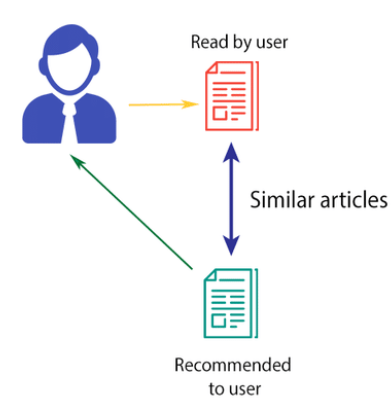

- 말 그대로 비슷한 item의 특성을 기반으로 추천해주는 것
- 유사도 기반으로 쉽게 구현 가능

In [3]:
# 라이브러리 가져오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# 실습파일 불러오기

# lyrics_by_1964_2023.csv
df = pd.read_csv("./data/lyrics_by_year_1964_2023.csv")
#1964 - 2023년 사이의 MELON 연도별 TOP100 노래 데이터
df

,id,year,title,singer,lyric,x_rated
0,30072384,1964,워싱턴광장,정 시스터즈,NaN,False
1,8150699,1964,황혼의 에레지,최양숙,NaN,False
2,5758967,1964,물새우는 해변,권혜경,고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 ...,False
3,4083218,1964,내일또 만납시다,금호동,하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\...,False
4,3622464,1964,밀짚모자 목장아가씨,박재란,시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술...,False
...,...,...,...,...,...,...
4661,31343875,2023,첫사랑,백아,알아 내 맘에 조용히\n문을 두드리면\n눈에 뿌옇게 고여버린\n널 흘려보내야 해\n...,False
4662,30962526,2023,모든 날 모든 순간 Every day Every Moment,폴킴,네가 없이 웃을 수 있을까\n생각만 해도 눈물이나\n힘든 시간 날 지켜준 사람\n이...,False
4663,30244931,2023,봄날,방탄소년단,보고 싶다\n이렇게 말하니까 더 보고 싶다\n너희 사진을 보고 있어도\n보고 싶다\...,False
4664,4446485,2023,너의 모든 순간,성시경,이윽고 내가 한눈에\n너를 알아봤을 때\n모든 건 분명 달라지고 있었어\n내 세상은...,False


| 컬럼명 | 설명 |
| --- | --- |
| id | 각 노래의 고유 식별자 |
| year | 노래가 발표된 연도 |
| title | 노래 제목 |
| singer | 노래 가수 이름 |
| lyric | 노래 가사 |
| x_rated | X-rated 여부 |

In [ ]:
# df정보 확인해서 결측치 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4666 entries, 0 to 4665
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       4666 non-null   int64 
 1   year     4666 non-null   int64 
 2   title    4666 non-null   object
 3   singer   4666 non-null   object
 4   lyric    4458 non-null   object
 5   x_rated  4666 non-null   bool  
dtypes: bool(1), int64(2), object(3)
memory usage: 187.0+ KB


In [ ]:
# 결측치 삭제 / 인덱스 재설정
df = df.dropna().reset_index(drop=True)
# reset_index로 제거한 인덱스를 컬럼으로 넣음 → drop=True를 설정해서 추가된 컬럼 삭제

In [ ]:
# 결측치가 삭제됐는지 확인
df.isnull().sum()

,0
id,0
year,0
title,0
singer,0
lyric,0
x_rated,0


### 가사(lyric)를 활용한 유사도 기반 추천 시스템 만들기

### 1. 전처리 진행
- 특수문자 제거 → 정규표현식 활용

In [ ]:
# re모듈 활용해서 영어(대소문자), 숫자, 한글, 띄어쓰기, 온점, 물음표, 느낌표를 제외한 특수문자 제거

# 정제된 가사를 cleaned_lyric 이라는 새로운 컬럼에 추가하기

In [ ]:
# re 모듈 불러오기
import re

In [ ]:
pattern = r"[^a-zA-Z0-9가-힣\s\.\?\!]"

In [ ]:
# 반복문을 통해 데이터에 모두 패턴 적용
from tqdm import tqdm
# 가사 정제 후 새로운 list에 넣어주기
cleaned_lyric = [re.sub(pattern,"",lyric)for lyric in df["lyric"]]

In [ ]:
cleaned_lyric[:5]

['고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 물새의 울음소리\n쓸쓸한 내 마음 속에 슬픔을 주네\n고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 물새의 울음소리\n쓸쓸한 내 마음 속에 슬픔을 주네\n',
 '하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\n가로등 하나 둘 꽃 피네\n허공을 스치는 바람은 차고\n흐뭇한 마음은 애드베룬\n가벼운 발길 헤어질 때 인사는\n내일 또 다시 만납시다\n하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\n가로등 하나 둘 꽃 피네\n허공을 스치는 바람은 차고\n흐뭇한 마음은 애드베룬\n가벼운 발길 헤어질 때 인사는\n내일 또 다시 만납시다\n내일 또 다시 만납시다\n',
 '시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술에는\n살며시 웃음 띄우고\n넓다란 푸른 목장\n하늘에 구름가네\n라라라 라라라라라\n라라라라 라라라라\n라라라 라라라라라\n라라라라 라라라라\n연분홍 빛 입술에는\n살며시 웃음 띄우고\n넓다란 푸른 목장\n하늘에 구름가네\n구름가네 음음음음\n',
 '비가 나리네 비가 나리네\n돌아선 이가슴에\n그님은 어데 그어느곳에\n이마음 벗사려 떨어져가도\n이마음 몹쓸건 미련때문에\n아 몸부림치며 님을 불렀네\n이마음 모질게 헤어져가고\n이마음 몹쓸건 미련때문에\n아 목놓아 울며 님을 불렀네\n',
 '잊지 못할 빗속의 여인\n지금은 어데 있나\n\n노오란 레인코트에\n검은 눈동자 잊지 못하네\n\n다정하게 미소지며\n검은 우산을 받쳐주네\n나리는 빗방울 바라보며\n말없이 말없이 걸었네\n\n잊지 못할 빗속의 여인\n그 여인을 잊지 못하네\n\n다정하게 미소지며\n검은 우산을 받쳐주네\n나리는 빗방울 바라보며\n말없이 말없이 걸었네\n\n잊지 못할 빗 속의 여인\n그 여인을 잊지 못하네\n\n오 잊지 못할 빗 속의 여인\n그 여인을 잊지 못

In [ ]:
# 정제된 가사를 cleaned_lyric 이라는 새로운 컬럼에 추가하기
df["cleaned_lyric"] = cleaned_lyric

In [ ]:
df.head(3)

,id,year,title,singer,lyric,x_rated,cleaned_lyric
0,5758967,1964,물새우는 해변,권혜경,고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 ...,False,고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 ...
1,4083218,1964,내일또 만납시다,금호동,하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\...,False,하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\...
2,3622464,1964,밀짚모자 목장아가씨,박재란,시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술...,False,시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술...


### 형태소 분석 및 불용어 처리

In [ ]:
# 1. 도구 설치 필요
# kiwipiepy, konpy 설치
!pip install konlpy
!pip install kiwipiepy

In [ ]:
# 2. kiwi에서 불용어 리스트 가져오기
from kiwipiepy.utils import Stopwords
# 2-1. 불용어 사전 객체 초기화
stopwords = Stopwords()
# 2-2. 불용어 사전의 단어들만 추출
stopwords_list = [word for word, tag in stopwords.stopwords]

In [ ]:
# 3. Okt, Kiwi 형태소 분석기 객체 생성
from konlpy.tag import Okt
from kiwipiepy import Kiwi

okt = Okt() # 형태소 분석 (품사 태깅)
kiwi = Kiwi() # 띄어쓰기 교정용

### 활용하는 품사 : Adjective(형용사), Verb(동사), Adverb(부사), Exclamation(감탄사)

In [ ]:
# 4. 토큰화 함수 정의 → pos_tagging(text)
def pos_tagging(text):
    # 4-1. 띄어쓰기 교정 (함수 내부로 들여쓰기)
    text = kiwi.space(text)

    # 4-2. 품사 태깅(형태소 분석)
    pos_words = okt.pos(
        text,
        stem = True, # 어간추출
        norm = True  # 표현 정규화
    )

    # 4-3. 원하는 품사만 추출 + 불용어 제거
    tagged_list = []

    # for문이 함수 내부에 있어야 pos_words를 인식할 수 있습니다.
    for word, tag in pos_words:
        if tag in ["Adjective", "Verb", "Adverb", "Exclamation"]:
            # stopwords_list가 사전에 정의되어 있어야 합니다.
            if word not in stopwords_list:
                tagged_list.append(word)

    # 마지막 return이 함수에 속하도록 들여쓰기를 맞춰줍니다.
    return tagged_list

In [ ]:
# 5. 함수 작동 테스트 (첫번째 줄 가사 뽑아서)
pos_tagging(df["cleaned_lyric"].iloc[1])

['끝내다',
 '돌아가다',
 '반짝이다',
 '스치다',
 '흐뭇하다',
 '가볍다',
 '헤어지다',
 '만나다',
 '끝내다',
 '돌아가다',
 '반짝이다',
 '스치다',
 '흐뭇하다',
 '가볍다',
 '헤어지다',
 '만나다',
 '만나다']

In [ ]:
# 6. 전체 데이터 적용
from tqdm import tqdm
tagged_lyric = [pos_tagging(text) for text in tqdm(df["cleaned_lyric"])]

100%|██████████| 4458/4458 [04:14<00:00, 17.52it/s]


In [ ]:
# 7. tagged_lyric 새로운 컬럼에 저장
df["tagged_lyric"] = tagged_lyric

In [ ]:
df.head(3)

,id,year,title,singer,lyric,x_rated,cleaned_lyric,tagged_lyric
0,5758967,1964,물새우는 해변,권혜경,고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 ...,False,고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 ...,"[잠들다, 밀리다, 들다, 외롭다, 날다, 쓸쓸하다, 잠들다, 밀리다, 들다, 외롭..."
1,4083218,1964,내일또 만납시다,금호동,하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\...,False,하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\...,"[끝내다, 돌아가다, 반짝이다, 스치다, 흐뭇하다, 가볍다, 헤어지다, 만나다, 끝..."
2,3622464,1964,밀짚모자 목장아가씨,박재란,시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술...,False,시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술...,"[시원하다, 몰다, 가다, 살며시, 띄우다, 넓다, 가다, 살며시, 띄우다, 넓다,..."


In [ ]:
import pickle
with open("./data/tagged_lyric.pkl", "wb") as f :
  pickle.dump(df,f)

### 다음 실습부터는 아래부터 진행

In [5]:
# 임베딩 진행 → gensim
!pip -q install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.2 MB/s eta 0:00:00


In [ ]:
# 구글 드라이브에서 파일을 읽어오고 쓰고 등의 작업을 하기 위해서 구글 드라이브에 연결 (마운트)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 작업 디렉토리 변경
%cd /content/drive/MyDrive/00\ 텍스트\ 마이닝

/content/drive/MyDrive/00 텍스트 마이닝


In [6]:
import gensim

In [7]:
import pandas as pd

import pickle
with open("./data/tagged_lyric.pkl", "rb") as f :
  df = pickle.load(f)

## doc2vec??
 - word2vec은 단어 하나를 하나의 vector화 (2013년 제안)
   - 주요 모델 : CBOW, Skip Gram
 - doc2vec은 문서 하나를 하나의 vector화 (2015년 제안)
   - 주요 모델 : PV-DM model, PV-DBoW

<center>  
<img src="https://arome1004.cafe24.com/images/machine_learning/dcx03.png" width=60%>   
</center>

- 벡터화된 데이터 시각화

<center>  
<img src="https://arome1004.cafe24.com/images/machine_learning/dcx04.png" width=40%>   
</center>

- DM : Distributed Memory
  - 벡터와 앞의 단어들을 사용해서 다음에 나오는 단어를 유추
  - 윈도우 크기 내의 단어들을 input으로 사용
  - 맨 앞에서부터 한 단어씩 훈련 데이터로 사용
  - 하나의 중심 단어를 output으로 학습 시키는 모델
  - 벡터가 학습 시 문서의 주제를 잡아주는 메모리와 같은 역할을 수행
  - 일반적으로 DBoW보다 더 성능이 우수
- DBoW : Distributed Bag Of Word
  - ID를 가지고 단어를 랜덤하게 예측하는 방식을 사용

In [8]:
# 필요한 도구들 불러오기
import gensim
from gensim.models.doc2vec import TaggedDocument

In [9]:
# TaggedDocument 사용해보기
TaggedDocument(
    tags = ["document 0"], # 각 문서를 구분할 수 있는 태그(문서 ID)
    words = df["tagged_lyric"][0]
)
# tags의 경우, 리스트로 묶어서 여러 문서 태그를 부여할 수 있지만
# 보통은 문서별로 하나의 태그만 사용하는 경우가 많음

TaggedDocument(words=['잠들다', '밀리다', '들다', '외롭다', '날다', '쓸쓸하다', '잠들다', '밀리다', '들다', '외롭다', '날다', '쓸쓸하다'], tags=['document 0'])

In [10]:
# 하나 하나씩 TaggedDocument로 변환

tagged_corpus_list = [] # 변환된 결과 쌓아주는 리스트
for i, tokens in enumerate(df["tagged_lyric"]) :
  tag = f"document {i}"
  tagged_doc = TaggedDocument(tags=[tag], words = tokens)
  tagged_corpus_list.append(tagged_doc)

In [11]:
len(tagged_corpus_list)

4458

### doc2vec 학습

In [12]:
from gensim.models.doc2vec import Doc2Vec

In [13]:
# docvec 모델 초기화
model = Doc2Vec(
    vector_size = 300, # 학습 할 벡터 (임베딩)의 차원 수
    alpha = 0.025,     # 초기 학습률
    min_alpha = 0.001, # 학습 진행 중에 점차 감소 시킬 최소 학습률
    window = 8,        # 주변 단어 범위 설정 (앞, 뒤 8개의 단어 확인)
    min_count = 2,     # 최소 등장 횟수 : n회 미만 단어는 제외
    dm=1               # 1 : pv-dm, 0 : DBOW
)

In [14]:
# 단어 사전 생성
# 문서별로 TaggedDocument를 만들었기 때문에 그걸 바탕으로 문서들 안에 등장하는 단어를 파악
model.build_vocab(tagged_corpus_list)

In [15]:
# doc2vec 모델 학습
# 문서 + 단어 기반으로 학습 진행
model.train(
    tagged_corpus_list,
    total_examples= model.corpus_count, # 전체 문서 개수
    epochs = 5
)

In [16]:
# 결과 확인
# TaggedDocument 생성할때 넣어준 문서 ID로 문서 벡터 확인 가능
model.dv["document 0"].shape

(300,)

### 문서 벡터값 DF에 추가

In [17]:
vector_list = [model.dv[f'document {i}'] for i in range(len(df))]

In [18]:
vector_list[:3]

[array([ 3.27636395e-03,  1.16771657e-03, -1.63182348e-03,  2.10123230e-03,
         5.21205319e-03, -2.47417460e-03, -5.00295218e-03, -1.39541412e-02,
        -4.91513172e-03, -1.15310703e-03,  3.35107790e-04,  1.71962148e-03,
         4.76770522e-03,  1.09839411e-02,  1.50349038e-02, -7.65255000e-03,
        -1.69295575e-02, -4.82218806e-03,  4.01526503e-03,  6.01191912e-03,
        -1.63937616e-03,  8.91449209e-03, -1.41601609e-02,  5.98980859e-03,
        -1.89973158e-03,  4.45296708e-03, -1.19310652e-03, -2.62861187e-03,
        -1.10610772e-03,  7.54474616e-03,  3.29753314e-03,  3.46406014e-03,
        -7.81226112e-03, -2.90513784e-03, -3.51198833e-03,  2.76534469e-03,
        -7.66966376e-04,  1.67717121e-03, -3.25893564e-03, -4.26797476e-03,
        -5.76062687e-03,  2.52864254e-03,  1.63146516e-03, -9.13153309e-03,
        -3.52905225e-03, -5.46223344e-03, -2.62585212e-03, -4.58782510e-04,
        -1.83740736e-03, -9.39485896e-03,  6.16950588e-03, -3.21067125e-03,
        -3.5

In [19]:
df["doc2vec_vector"] = vector_list

In [20]:
df.head(3)

,id,year,title,singer,lyric,x_rated,cleaned_lyric,tagged_lyric,doc2vec_vector
0,5758967,1964,물새우는 해변,권혜경,고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 ...,False,고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 ...,"[잠들다, 밀리다, 들다, 외롭다, 날다, 쓸쓸하다, 잠들다, 밀리다, 들다, 외롭...","[0.003276364, 0.0011677166, -0.0016318235, 0.0..."
1,4083218,1964,내일또 만납시다,금호동,하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\...,False,하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\...,"[끝내다, 돌아가다, 반짝이다, 스치다, 흐뭇하다, 가볍다, 헤어지다, 만나다, 끝...","[0.001165836, 0.0026500786, -0.007879383, 0.00..."
2,3622464,1964,밀짚모자 목장아가씨,박재란,시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술...,False,시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술...,"[시원하다, 몰다, 가다, 살며시, 띄우다, 넓다, 가다, 살며시, 띄우다, 넓다,...","[2.3173256e-05, 0.001957759, 0.0014530683, -0...."


### 유사도 기반 추천기능 구현

1. 가사 기반의 코사인 유사도 계산
2. 추천 함수(기능)정의

In [61]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [63]:
# 예시 데이터 설정
doc_index = 3000

In [64]:
# 대상 곡의 벡터 추출
target_vector = df.loc[doc_index, "doc2vec_vector"].reshape(1,-1)
target_vector.shape

# cosine_similarity 함수가 2D 배열의 입력 값을 기대함
# 기존 문서 벡터가 1차원 벡터여서 2차원으로 변환해줌
# reshape(1,-1) : 배열을 (1행, 자동 계산 된 열)로 재구성

(1, 300)

In [65]:
# 전체 곡 벡터를 하나의 배열로 생성
all_vectors = np.stack(df["doc2vec_vector"].values, axis = 0)
# 여러개의 id 배열을 세로 방향(행)으로 쌓여서 2차원 배열로 만듦
all_vectors.shape

(4458, 300)

In [66]:
# 대상 곡(단일)과 전체 곡(다중) 간의 코사인 유사도 계산
similarity_scores = cosine_similarity(target_vector, all_vectors)
similarity_scores.shape

(1, 4458)

In [67]:
# 1차원 배열로 다시 펴주기!
similarity_scores = similarity_scores.flatten()
similarity_scores.shape

(4458,)

In [68]:
# 대상 곡의 인덱스가 3000번 -> 3000번의 점수가 가장 높을건데
# 대상 곡을 추천결과에서 제외하기 위해 유사도 값을 -1로 설정
similarity_scores[doc_index] = -1

In [69]:
# 유사도가 높은 상위 10개의 곡 인덱스를 추출
top_n = 10
top_idx = similarity_scores.argsort()[::-1][:top_n]
# .argsort() : 배열 내의 값들을 오름차순으로 정렬했을 때, 각 값이 원래 배열에서 어떤 인덱스에 있었는지를 반환
# [::-1] : 역순으로 모든 값들을 가져와서 내림차순으로 만듦

top_idx # 유사도가 높은 값부터 낮은 값 순서의 인덱스를 얻음!

array([2368, 3484, 3307, 3369, 3680,  780, 2250,  684, 3661,  668])

In [70]:
# 최종 추천 결과 구성(곡 id, title, singer, year + 유사도 점수)

# 대상 곡 df
target_df = df.loc[[doc_index], ["title", "singer", "year", "lyric"]].copy()

# 추천 곡의 df
result_df = df.loc[top_idx, ["title", "singer", "year", "lyric"]].copy()
result_df["similarity"] = similarity_scores[top_idx]

display(target_df)
display(result_df)

,title,singer,year,lyric
3000,YOU AND I,박봄 Park Bom,2009,No matter what happens\nEven when the sky is f...


,title,singer,year,lyric,similarity
2368,No1,보아 BoA,2002,어둠속에 니 얼굴 보다가\n\n나도 몰래 눈물이 흘렀어\n\n소리 없이 날 따라오며...,0.885584
3484,바람기억,나얼,2013,바람 불어와 내 맘 흔들면\n지나간 세월에\n두 눈을 감아본다\n나를 스치는 고요한...,0.866665
3307,바람기억,나얼,2012,바람 불어와 내 맘 흔들면\n지나간 세월에\n두 눈을 감아본다\n나를 스치는 고요한...,0.857149
3369,Falling,존박,2012,하얗게 번지는 머릿속에다\n그대를 새겨놓고 저 멀리 날아가\n모든 게 보이는 두 눈...,0.845902
3680,바람기억,나얼,2015,바람 불어와 내 맘 흔들면\n지나간 세월에\n두 눈을 감아본다\n나를 스치는 고요한...,0.843410
780,아이스크림 사랑,임병수,1986,길을 걸으면\n밝은 햇살이\n흘러내려와\n나를 부르네\nChiquilla mia S...,0.839664
2250,꿈을 모아서 Just In Love,SES,2001,그대에게 줄게요 나의\n모든 사랑을\n세상에서 오직 하나뿐인\n당신을 위해서\n당신...,0.827894
684,J 그대는,오복,1985,J 그대는 희미한 작은 불빛처럼\n외로운 이밤에 쓸쓸한 이밤에\n나에게 슬픔을 주네...,0.826400
3661,환청 Feat 나쑈 NaShow,장재인JEIN,2015,내 안에 숨은 것들이 말이야\n날 참 많이 변하게 했잖아\n날 잠재우고 두 손 묶고...,0.825887
668,사랑의 미로,최진희,1984,그토록 다짐을 하건만\n사랑을 알 수 없어요\n사랑으로 눈먼 가슴은\n진실하나에 울...,0.818204


In [ ]:
# 대상 곡의 index를 바꿔서 직접 해보기!

In [49]:
# 예시 데이터 설정
doc_index2 = 4000

# 대상 곡의 벡터 추출
target_vector2 = df.loc[doc_index2, "doc2vec_vector"].reshape(1,-1)
target_vector2.shape

# cosine_similarity 함수가 2D 배열의 입력 값을 기대함
# 기존 문서 벡터가 1차원 벡터여서 2차원으로 변환해줌
# reshape(1,-1) : 배열을 (1행, 자동 계산 된 열)로 재구성

(1, 300)

In [50]:
# 전체 곡 벡터를 하나의 배열로 생성
all_vectors = np.stack(df["doc2vec_vector"].values, axis = 0)
# 여러개의 id 배열을 세로 방향(행)으로 쌓여서 2차원 배열로 만듦
all_vectors.shape

(4458, 300)

In [51]:
# 대상 곡(단일)과 전체 곡(다중) 간의 코사인 유사도 계산
similarity_scores2 = cosine_similarity(target_vector2, all_vectors)
similarity_scores2.shape

(1, 4458)

In [52]:
# 1차원 배열로 다시 펴주기!
similarity_scores2 = similarity_scores2.flatten()
similarity_scores2.shape

(4458,)

In [53]:
# 대상 곡의 인덱스가 2000번 -> 2000번의 점수가 가장 높을건데
# 대상 곡을 추천결과에서 제외하기 위해 유사도 값을 -1로 설정
similarity_scores2[doc_index2] = -1

In [54]:
# 유사도가 높은 상위 10개의 곡 인덱스를 추출
top_n_2 = 10
top_idx_2 = similarity_scores2.argsort()[::-1][:top_n_2]
# .argsort() : 배열 내의 값들을 오름차순으로 정렬했을 때, 각 값이 원래 배열에서 어떤 인덱스에 있었는지를 반환
# [::-1] : 역순으로 모든 값들을 가져와서 내림차순으로 만듦

top_idx_2 # 유사도가 높은 값부터 낮은 값 순서의 인덱스를 얻음!

array([1105, 2773, 4406, 2738, 2085, 1336, 3175, 1655,  922, 1386])

In [55]:
# 최종 추천 결과 구성(곡 id, title, singer, year + 유사도 점수)

# 대상 곡 df
target_df_2 = df.loc[[doc_index2], ["title", "singer", "year", "lyric"]].copy()

# 추천 곡의 df
result_df_2 = df.loc[top_idx_2, ["title", "singer", "year", "lyric"]].copy()
result_df_2["similarity"] = similarity_scores2[top_idx_2]

display(target_df_2)
display(result_df_2)

,title,singer,year,lyric
4000,Kill This Love,BLACKPINK,2019,천사 같은 Hi 끝엔 악마 같은 Bye\n매번 미칠듯한 High 뒤엔 뱉어야\n하는...


,title,singer,year,lyric,similarity
1105,제주도의 푸른밤,최성원,1989,떠나요 둘이서\n모든 것 훌훌 버리고\n제주도 푸른 밤\n그 별 아래\n이제는 더 ...,0.972800
2773,전부 너였다,노을,2006,가슴을 떼어논채\n살 순 없나요\n아무런 느낌도 없는 채로\n눈물을 닦을 힘도 숨쉴...,0.969984
4406,떠나보낼 준비해 둘걸 그랬어,임한별,2023,너랑 입으려 고른 옷 오늘 받아봤어\n오래 걸려서 잊고 있었는데\n곧 있을 너의 생...,0.967907
2738,헤어져야 사랑을 알죠,리사,2006,술에 취하지 않아도\n온종일 난 휘청거려요\n슬픔을 가누지 못해요\n수도 없이 얼러...,0.966675
2085,슬픈 선물,김장훈,1999,다 끝난 일인거니\n이젠 돌이킬수 없니\n널 잊고 살아가야 하는건\n나를 포기한다는...,0.965670
1336,더 이상 내게 아픔을 남기지마,하수빈,1992,지금 너의 차가운\n눈빛을 나는 알고있었어\n아쉬움도 느낄 수 없을만큼 짧은\n시간...,0.964929
3175,아프니까 사랑이죠,민경훈,2010,세상이 내게 미쳤다 말해도\n멈출수가 없네요 난 안돼요\n사랑이 내게 거두라 말해도...,0.963393
1655,고요속의 외침,Ref,1995,더 이상 나에게 너만을\n강요하지는 말아줘\n서둘러 가야할 이별에\n눈물은 장애가 ...,0.956982
922,내가 왜 웁니까,주현미,1987,울지않아요\n내가 왜웁니까\n내가 싫어 가는 사람앞에\n가슴을 돌여내는\n그아픔도 ...,0.955792
1386,처음 만날때처럼,윤종신,1992,졸린 눈을 비비며 꼬깃해진 너의 편질 읽었어\n마냥 즐거웠던 내 마음 한순간 무거워...,0.955744


In [71]:
# 전달인자로 추천받고 싶은 대상곡 인덱스, 곡 정보가 들어있는 DF, 상위 몇 개를 추천받을지(기본 10개로 설정)
def recommend_song_by_lyric(doc_index, df, top_n=10) :
  """
  doc_index : 추천을 원하는 곡의 DF 인덱스
  df : 전체 곡 정보가 들어있는 데이터프레임
  top_n : 상위 몇 개를 추천받을지(기본 10개)
  """

  # 1. 대상 곡의 벡터 추출
  target_vector = df.loc[doc_index, "doc2vec_vector"].reshape(1, -1)

  # 2. 전체 곡 벡터를 하나의 배열로 생성
  all_vectors = np.stack(df["doc2vec_vector"].values, axis=0)

  # 3. 대상 곡과 전체 곡 간의 코사인 유사도 계산 + 1차원으로 평탄화
  sim_score = cosine_similarity(target_vector, all_vectors).flatten()

  # 4. 자기 자신은 추천결과에서 제외하기 위해 유사도 값을 -1로 설정
  sim_score[doc_index] = -1

  # 5. 유사도가 높은 상위 10개의 곡의 인덱스 추출
  top_idx = sim_score.argsort()[::-1][:top_n]

  # 6. 최종 추천 결과 구성
  target_df = df.loc[[doc_index], ["title", "singer", "year", "lyric"]].copy()
  result_df = df.loc[top_idx, ["title", "singer", "year", "lyric"]].copy()
  result_df["similarity"] = similarity_scores[top_idx]

  return (target_df, result_df)

In [74]:
# 함수 테스트
target_info, recommendation = recommend_song_by_lyric(2855, df, 15)

display(target_info)
display(recommendation)

,title,singer,year,lyric
2855,하루살이,BMK,2007,그리움은 부지런도 해\n내가 눈을 뜨기만을 기다린듯 해\n네가 변했는데\n세상은 하...


,title,singer,year,lyric,similarity
371,세월,최헌,1977,세월이 흘러가면 잊을 날도 있다지만\n그러나 언젠가는 그리울거야\n눈가에 맺히는 눈...,0.412918
2326,Suddenly,제이워크,2002,Suddenly 이렇게 나에게\n찾아 온 슬픔이 너무도 힘든걸\nJust for y...,0.378158
864,빛바랜 사랑,오선과 한음,1986,가슴에 새기던 그 밤 그 약속\n이제는 빛 바랜\n사랑이 되어버렸네\n울고 싶은 사...,0.391534
4014,술이 달다 Feat Crush,에픽하이 EPIK HIGH,2019,흔들 흔들거리는 다리와\n빙글빙글 도는 내 머리가 널\n널 지우는 중\n울렁 울렁거...,0.340465
988,가을비,유열,1988,비가 오는데\n끝없이 창문을 적시는데\n내곁을 떠난 그대는\n어디서 무얼하나\n그리...,0.558235
1073,약속은 바람처럼,민해경,1989,약속을 잊으셨나요 그대\n사랑을 모르셨나요 그대\n잡지도 못한 내가 바보였나봐\n왠...,0.407999
3934,그리워하다,비투비,2018,My life is incomplete\nIt’s Missing you\n오늘도 하...,0.259555
581,바람이었나,정수라,1983,이제는 너를 잊어야 하나\n그냥 스쳐가는 바람처럼\n파란 미소를 뿌리던\n꿈의 계절...,0.384085
630,얼룩진 상처,백영규,1984,저 멀리 사라진 너의 발길\n눈물속에 아른거리고\n붙잡지도 못하는 나의 가슴\n서러...,0.559279
852,허공,조용필,1986,꿈이었다고 생각하기엔\n너무나도 아쉬움 남아\n가슴태우며 기다리기엔\n너무나도 멀어...,0.361809


### 메타 데이터를 활용한 추천 성능 개선
- 가사 외에도 연도, 가수 정보를 추가해서 추천 성능을 개선

In [75]:
# 테스트 대상 곡 인덱스 지정
test_index = 3538

In [76]:
# 대상 곡의 Doc2Vec 벡터 추출 및 2D 배열로 변환
target_vector = df.loc[test_index, "doc2vec_vector"].reshape(1, -1)
# - df.loc[test_index, "doc2vec_vector"]: 지정한 인덱스의 곡에 해당하는 Doc2Vec 벡터를 가져옴
# - reshape(1, -1): cosine_similarity 함수가 2D 배열을 요구하므로, 1행 다열 형태로 변환

In [77]:
# 전체 곡의 Doc2Vec 벡터를 하나의 2D 배열로 결합
all_vectors = np.stack(df["doc2vec_vector"].values, axis=0)
# - df["doc2vec_vector"].values: 각 곡의 Doc2Vec 벡터들을 추출
# - np.stack(..., axis=0): 여러 1D 벡터들을 행 방향(첫 번째 축)으로 결합하여 2D 배열(각 행=하나의 곡)로 생성

In [78]:
# 대상 곡과 전체 곡 간의 코사인 유사도 계산 후 1D 배열로 변환
lyric_sim = cosine_similarity(target_vector, all_vectors).flatten()
# - cosine_similarity(target_vector, all_vectors): 대상 곡과 모든 곡 간의 코사인 유사도를 계산 (결과는 2D 배열)
# - flatten(): 2D 배열을 1D 배열로 변환하여 각 원소가 대상 곡과 해당 곡 간의 유사도를 나타냄

연도 유사도 계산

In [79]:
# 대상 곡의 발매 년도 추출
target_year = df.loc[test_index, "year"]
target_year

np.int64(2014)

In [80]:
# 전체 곡의 연도 배열을 생성
# 스케일러 활용을 위한 1차원 배열 -> 2차원 배열로 변환
all_years = df["year"].values.reshape(-1, 1)
all_years

array([[1964],
       [1964],
       [1964],
       ...,
       [2023],
       [2023],
       [2023]])

In [81]:
# 대상 곡과 모든 곡 간의 연도 차이의 절대값 계산
year_diff = np.abs(all_years - target_year)
year_diff

array([[50],
       [50],
       [50],
       ...,
       [ 9],
       [ 9],
       [ 9]])

In [82]:
# 스케일러 활용
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
year_diff_scaled = scaler.fit_transform(year_diff)
year_diff_scaled

# 차이가 크면(연도 차이가 많이 나면) 값이 1에 가깝고, 차이가 작으면 0에 가까움
# 추천의 개념에서는 유사도가 높을수록 값이 1에 가깝고, 낮을수록 0에 가까워야 함

array([[1.  ],
       [1.  ],
       [1.  ],
       ...,
       [0.18],
       [0.18],
       [0.18]])

In [83]:
# 연도의 차이가 적을수록 1에 값이 가까워지게 처리
year_sim_scaler = 1-year_diff_scaled.flatten()
year_sim_scaler

array([0.  , 0.  , 0.  , ..., 0.82, 0.82, 0.82])

가수 유사도 계산

In [84]:
# 일치하는지 아닌지 확인만 해보자!
target_singer = df.loc[test_index, "singer"]
target_singer

'god'

In [87]:
# 전체 곡의 가수와 대상 곡의 가수를 비교하여 동일하면 1, 아니면 0
singer_sim = np.array([1 if singer==target_singer else 0 for singer in df["singer"].values])
singer_sim

array([0, 0, 0, ..., 0, 0, 0])

3가지 결과 종합!

In [88]:
# 각 요소에 부여할 가중치를 다르게 설정해서 저장
lyric_weight = 1.0
year_weight = 0.5
singer_weight = 0.2

In [89]:
# 각 유사도 값에 가중치를 곱한 후 합산해서 최종 유사도 계산
final_sim = (lyric_weight * lyric_sim) + (year_weight * year_sim_scaler) + (singer_weight * singer_sim)
final_sim

array([-0.10283314,  0.22540163, -0.37636518, ...,  0.5246806 ,
        0.19243208,  0.72905687])

In [90]:
# 자기 자신 추천에서 제외
final_sim[test_index] = -np.inf

In [91]:
# 최종 유사도가 높은 상위 10개 곡 인덱스 추출 및 출력
top_idx = np.argsort(final_sim)[::-1][:10]

# 대상 곡 df
target_df = df.loc[[test_index], ["title", "singer","year", "lyric"]].copy()


# 추천 곡의 df
result_df = df.loc[top_idx, ["title", "singer", "year", "lyric"]].copy()
result_df["similarity"] = similarity_scores[top_idx]

display(target_df)
display(result_df)

,title,singer,year,lyric
3538,미운오리새끼,god,2014,새벽 한 시 길을 걷는다\n저 강가에 오리 한 마리\n왜 내 모습 같은지\n시린 바...


,title,singer,year,lyric,similarity
3935,가을 안부,먼데이 키즈 Monday Kiz,2018,어떠니 잘 지냈니 지난 여름\n유난히도 힘에 겹더라 올핸\n새벽녘엔 제법 쌀쌀한 바...,-0.392047
3294,Officially Missing You Too,긱스 Geeks 소유 SOYOU,2012,애써 너에게 건냈던 말 good bye\n이젠 혼자 남게된 이 밤 without y...,-0.401636
3403,나란놈이란,임창정,2013,그대를 잊는다는 건 지금의\n나로선 좀 힘들 거 같아\n아무리 원망을 해도 어느새\...,-0.306227
3483,Officially Missing You Too,긱스 Geeks 소유 SOYOU,2013,애써 너에게 건냈던 말 good bye\n이젠 혼자 남게된 이 밤 without y...,-0.217072
4088,덤더럼 Dumhdurum,Apink 에이핑크,2020,Hey 느낌이 너무 이상한 걸 좀\n나를 위해 보내준다는 말이\n직감은 두려워 너무...,-0.233385
2245,연인戀人,박상민,2001,너를 잊기 위해서\n어떻게 해야하는지\n이제와서 후회한다 해도\n아무런 소용 없겠지...,-0.549731
2408,잊었니,현승민H,2003,잊었니 네가 고백했던\n그 말 잊었니\n날 버리지 않겠다던 그 약속\n그렇게 쉬운 ...,-0.413476
3623,아프다,지코 ZICO,2015,나란 존재가 존재하긴 했어\n혀끝까지 차오른 말을 삼켜내\n너만 나쁜 년 만드는 구...,-0.215743
3581,신촌을 못가,포스트맨 POSTMEN,2014,신촌을 못가 한번을 못가\n혹시 너와 마주칠까 봐\n널 보면 눈물이 터질까 봐\n친...,-0.436311
3350,떠나간다,노을,2012,나는 괜찮아\n내가 널 잊어야 행복할 수 있다면\n이미 떠나버린 니맘을\n붙잡을 수...,0.038945


In [114]:
# 함수로 바꿔보기

def recommend_songs_by_meta(doc_index, df, top_n=10, lyric_weight=1.0, year_weight=0.5, singer_weight=0.2) :

  # *** 가사 유사도 계산 ***
  # 대상 곡의 임베딩 벡터
  target_vector = df.loc[doc_index, "doc2vec_vector"].reshape(1, -1)
  all_vectors = np.stack(df["doc2vec_vector"].values, axis=0)
  # 대상 곡과 전체 곡간의 코사인 유사도를 계산 → 1d 변환
  lyric_sim = cosine_similarity(target_vector, all_vectors).flatten()
  # *** 연도 유사도 계산 ***
  # 대상 곡과 다른 곡들의 연도 차이를 계산 → 정규화(0~1)
  target_year = df.loc[doc_index, "year"]
  all_years = df["year"].values.reshape(-1, 1)
  year_diff = np.abs(all_years - target_year)
  scaler = MinMaxScaler()
  year_diff_scaled = scaler.fit_transform(year_diff)
  year_sim_scaler = 1 - year_diff_scaled.flatten()
  # *** 가수 유사도 계산 ***
  target_singer = df.loc[doc_index, "singer"]
  singer_sim = np.array([1 if singer==target_singer else 0 for singer in df["singer"].values])
  # 가중치 적용 후 최종 유사도 계산
  final_sim = (lyric_weight * lyric_sim) + (year_weight * year_sim_scaler) + (singer_weight * singer_sim)
  # 대상곡 유사도 가장 낮게 설정
  final_sim[doc_index] = -np.inf
  top_idx = np.argsort(final_sim)[::-1][:top_n]
  # 결과 df 구성
  target_df = df.loc[[doc_index], ["title", "singer","year", "lyric"]].copy()
  rec_df = df.loc[top_idx, ["title", "singer", "year", "lyric"]].copy()
  rec_df["similarity"] = final_sim[top_idx]

  return (target_df, rec_df)

#  """
#     메타데이터(가사, 연도, 가수)를 활용한 추천 시스템.
#     주어진 곡(doc_index)을 기준으로 가사, 연도, 가수 유사도를 계산한 후,
#     각 유사도에 가중치를 곱해 최종 유사도를 산출하고, 상위 top_n곡을 추천한다.

#     매개변수:
#     - doc_index   : 추천 기준이 되는 곡의 DataFrame 인덱스
#     - df          : 전체 곡 정보가 담긴 DataFrame (doc2vec_vector, year, singer 컬럼 포함)
#     - top_n       : 추천할 곡의 개수 (기본 10개)
#     - lyric_weight: 가사 유사도에 부여할 가중치 (기본 1.0)
#     - year_weight : 연도 유사도에 부여할 가중치 (기본 0.5)
#     - singer_weight: 가수 유사도에 부여할 가중치 (기본 0.2)

#     반환:
#     - target_df : 기준 곡의 정보 (title, singer, year, lyric)
#     - rec_df    : 추천된 곡들의 정보 및 최종 유사도(final_similarity)를 포함한 DataFrame
#     """

In [115]:
# 함수 테스트
target_info, recommendation = recommend_songs_by_meta(4100, df)

display(target_info)
display(recommendation)

,title,singer,year,lyric
4100,친구,방탄소년단,2020,유난히도 반짝였던 서울\n처음 보는 또 다른 세상\n땀에 잔뜩 밴 채 만난 넌\n뭔...


,title,singer,year,lyric,similarity
3997,Make It Right,방탄소년단,2019,내가 날 눈치챘던 순간\n떠나야만 했어\n난 찾아내야 했어\nAll day all ...,1.557057
3889,전하지 못한 진심 Feat Steve Aoki,방탄소년단,2018,외로움이 가득히\n피어있는 이 garden\n가시투성이\n이 모래성에 난 날 매었어...,1.525028
3998,소우주 Mikrokosmos,방탄소년단,2019,반짝이는 별빛들\n깜빡이는 불 켜진 건물\n우린 빛나고 있네\n각자의 방 각자의 별...,1.517053
3939,DNA,방탄소년단,2018,첫눈에 널 알아보게 됐어\n서롤 불러왔던 것처럼\n내 혈관 속 DNA가 말해줘\n내...,1.496647
3766,DNA,방탄소년단,2017,첫눈에 널 알아보게 됐어\n서롤 불러왔던 것처럼\n내 혈관 속 DNA가 말해줘\n내...,1.471411
4098,We are Bulletproof the Eternal,방탄소년단,2020,가진 게 꿈밖에 없었네\n눈 뜨면 뿌연 아침뿐\n밤새 춤을 추며 노래해\n그 끝이 ...,1.464764
4155,봄날,방탄소년단,2020,보고 싶다\n이렇게 말하니까 더 보고 싶다\n너희 사진을 보고 있어도\n보고 싶다\...,1.464538
4056,봄날,방탄소년단,2019,보고 싶다\n이렇게 말하니까 더 보고 싶다\n너희 사진을 보고 있어도\n보고 싶다\...,1.460377
4103,ON,방탄소년단,2020,I can't understand what people are sayin'\n어느 ...,1.455551
4147,작은 것들을 위한 시 Boy With Luv Feat Halsey,방탄소년단,2020,모든 게 궁금해\nHow’s your day\nOh tell me\n뭐가 널 행복하...,1.450886


In [112]:
def recommend_songs_by_meta(doc_index, df, top_n = 10, lyric_weight=1.0, year_weight=0.5, singer_weight=0.2) :
    """
    메타데이터(가사, 연도, 가수)를 활용한 추천 시스템.
    주어진 곡(doc_index)을 기준으로 가사, 연도, 가수 유사도를 계산한 후,
    각 유사도에 가중치를 곱해 최종 유사도를 산출하고, 상위 top_n곡을 추천한다.

    매개변수:
    - doc_index   : 추천 기준이 되는 곡의 DataFrame 인덱스
    - df          : 전체 곡 정보가 담긴 DataFrame (doc2vec_vector, year, singer 컬럼 포함)
    - top_n       : 추천할 곡의 개수 (기본 10개)
    - lyric_weight: 가사 유사도에 부여할 가중치 (기본 1.0)
    - year_weight : 연도 유사도에 부여할 가중치 (기본 0.5)
    - singer_weight: 가수 유사도에 부여할 가중치 (기본 0.2)

    반환:
    - target_df : 기준 곡의 정보 (title, singer, year, lyric)
    - rec_df    : 추천된 곡들의 정보 및 최종 유사도(final_similarity)를 포함한 DataFrame
    """
    # *** 가사 유사도 계산 ***
    # 대상 곡의 임베딩 벡터
    target_vector = df.loc[doc_index, "doc2vec_vector"].reshape(1, -1)
    all_vectors = np.stack(df["doc2vec_vector"].values, axis=0)

    # 대상 곡과 전체 곡간의 코사인 유사도를 계산 → 1d 변환
    lyric_sim = cosine_similarity(target_vector, all_vectors).flatten()

    # *** 연도 유사도 계산 ***
    # 대상 곡과 다른 곡들의 연도 차이를 계산 → 정규화(0~1)
    target_year = df.loc[doc_index, "year"]
    all_year = df["year"].values.reshape(-1, 1)

    year_diff = np.abs(all_year - target_year)

    scaler = MinMaxScaler()
    year_diff_scaled = scaler.fit_transform(year_diff)

    year_sim = 1 - year_diff_scaled.flatten()

    # *** 가수 유사도 계산 ***
    target_singer = df.loc[doc_index, "singer"]
    singer_sim = np.array([1 if singer == target_singer else 0 for singer in df["singer"].values])

    # 가중치 적용 후 최종 유사도 계산
    final_sim = (lyric_weight * lyric_sim) + (year_weight * year_sim) + (singer_weight * singer_sim)

    # 대상곡 유사도 가장 낮게 설정
    final_sim[doc_index] = -np.inf

    top_idx = np.argsort(final_sim)[::-1][:top_n]

    # 결과 df 구성
    target_df = df.loc[[doc_index], ["title", "singer", "year", "lyric"]].copy()
    result_df = df.loc[top_idx, ["title", "singer", "year", "lyric"]].copy()
    result_df["final_similarity"] = final_sim[top_idx]

    return target_df, result_df

> 이 외에도 아래 방법들로 성능 개선 가능
> - 최신 딥러닝 임베딩 활용 ```문서의 뉘앙스를 보다 세밀하게 포착 가능```
> - 하이브리드 필터링 방법 채택 ```콘텐츠 기반과 협업 필터링 방식을 결합하여 사용자 행동 데이터 반영```
> - 모델 및 파라미터 최적화
    - ```Doc2Vec 외 TF-IDF, LDA 등 다른 벡터화 기법과 앙상블 적용```
    - ```학습 epochs, vector_size, window 등 하이퍼파라미터 튜닝```
> - 전처리 및 토큰화 정교화 ```노이즈 제거, 중복 제거 등 데이터 클린징 강화```

# 콘텐츠 기반 필터링 추천시스템 정리

### 주요 특징
- <span style="color:red"><u><b>아이템 특성 활용:</b></u></span> 아이템(예: 가사, 장르, 연도, 가수 등)의 내용이나 메타데이터를 활용  
- <span style="color:red"><u><b>개별 아이템 분석:</b></u></span> 사용자가 평가한 아이템과 **유사한 속성**을 가진 다른 아이템 추천  
- <span style="color:red"><u><b>설명 가능성:</b></u></span> 추천 이유를 아이템의 특성으로 **명확하게 설명** 가능
- <u><b>초기 콜드 스타트</b></u> 문제에 대응 가능
    - Cold start : 서비스에 사용자나 아이템에 관한 정보가 적은 경우, 즉 <u><b>신규 사용자 혹은 신규 아이템을 추천하기 어려운 문제</b></u>
    - <u><b>협업 필터링</b></u>은 과거 사용자의 선호 데이터가 필요하므로 <u><b>콜드 스타트 문제에 취약함</b></u>
    - 콜드 스타트 문제와 성능 향상을 위해 <u><b>신규 고객에게는 콘텐츠 기반 필터링</b></u>, <u><b>특정 횟수 이상 구매 회원에게는 협업 필터링</b></u>을 적용하는 방식도 존재함

> 과도한 특수화 (Over Specialization) 문제 존재
> - 추천 상품의 다양성을 보장할 수 없는 문제

### 장점과 단점

| **구분** | **세부 내용** |
|----------|---------------|
| **장점** | - 설명 가능하고 직관적임<br>- 사용자의 개별 취향 반영 가능<br>- 사용자 데이터가 상대적으로 적어도 적용 가능 |
| **단점** | - 아이템의 특징에 한정되어 다양성이 부족할 수 있음<br>- <span style="color:red"><u><b>과도한 특수화 (Over Specialization)</b></u></span> 문제<br>- 콘텐츠 특징 추출 및 전처리 비용 발생<br>- 새로운 아이템의 경우 충분한 특징 추출이 어려움 (<span style="color:red"><u><b>Cold Start 문제</b></u></span>)<br>- 사용자가 기존에 소비한 아이템과 너무 유사한 추천 제공<br>- 콘텐츠 정보 부족 시 추천 성능 저하 |


### 콘텐츠 기반 필터링의 한계와 협업 필터링으로의 전환

> **한계 극복:**  
> - 콘텐츠 기반 필터링은 **아이템 내재적 정보**에 의존하므로, 사용자의 **잠재적 취향**이나 **다른 사용자와의 상호작용 정보**를 반영하기 어려움

> **협업 필터링 소개:**  
> - <span style="color:red"><u><b>사용자 행동 기반:</b></u></span> 여러 사용자의 평가나 소비 데이터를 활용하여 **사용자 간 혹은 아이템 간 유사도**를 산출  
> - <span style="color:red"><u><b>다양한 추천:</b></u></span> 콘텐츠 기반의 한계를 보완해 사용자의 **다양한 취향**과 **새로운 아이템**을 추천 가능  
> - <span style="color:red"><u><b>하이브리드 접근:</b></u></span> 콘텐츠 기반과 협업 필터링을 결합하여 **더욱 정교한 추천 시스템** 구현